## Loading Dataset

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split


# 0. Download dataset (run once, skip if already downloaded)

# !kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
# !unzip -q chest-xray-pneumonia.zip -d chest_xray_data

DATA_DIR = "chest_xray_data/chest_xray"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
SUBSET_PER_CLASS = 800   # target images per class for the baseline CNN subset

I0000 00:00:1785008428.706836    2029 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Preprocessing

In [2]:
# ------------------------------------------------------------------
# 1. Check class balance across original folders
# ------------------------------------------------------------------
print("Class counts per split:")

print(os.getcwd())
print(os.listdir())
print(os.listdir("chest_xray_data"))

for split in ["train", "test"]:
    for cls in ["NORMAL", "PNEUMONIA"]:
        path = f"{DATA_DIR}/{split}/{cls}"
        print(f"  {split}/{cls}: {len(os.listdir(path))}")


# 2. Build a stratified subset from train

def gather_filepaths(split):
    filepaths, labels = [], []
    for label, cls in enumerate(["NORMAL", "PNEUMONIA"]):  # 0=NORMAL, 1=PNEUMONIA
        cls_dir = f"{DATA_DIR}/{split}/{cls}"
        for fname in os.listdir(cls_dir):
            filepaths.append(os.path.join(cls_dir, fname))
            labels.append(label)
    return np.array(filepaths), np.array(labels)

train_files_all, train_labels_all = gather_filepaths("train")

# Stratified subset: take up to SUBSET_PER_CLASS images per class
subset_files, subset_labels = [], []
rng = np.random.default_rng(SEED)
for label in [0, 1]:
    idx = np.where(train_labels_all == label)[0]
    n = min(SUBSET_PER_CLASS, len(idx))
    chosen = rng.choice(idx, size=n, replace=False)
    subset_files.extend(train_files_all[chosen])
    subset_labels.extend(train_labels_all[chosen])

subset_files = np.array(subset_files)
subset_labels = np.array(subset_labels)
print(f"\nSubset size: {len(subset_files)} images "
      f"({np.sum(subset_labels==0)} NORMAL, {np.sum(subset_labels==1)} PNEUMONIA)")


# 3. Stratified 80/20 train/val split of the subset

train_files, val_files, train_labels, val_labels = train_test_split(
    subset_files, subset_labels,
    test_size=0.2, stratify=subset_labels, random_state=SEED
)
print(f"Train: {len(train_files)}  Val: {len(val_files)}")


# 4. Build tf.data pipelines from file paths

def load_and_preprocess(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0  # normalize to [0,1]
    return img, tf.expand_dims(tf.cast(label, tf.float32), axis=-1)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

def make_dataset(filepaths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(buffer_size=len(filepaths), seed=SEED)
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    return ds.prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_files, train_labels, training=True)
val_ds = make_dataset(val_files, val_labels, training=False)


# 5. Test set: use the FULL official test/ folder

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    f"{DATA_DIR}/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)
class_names = test_ds_raw.class_names
test_ds = test_ds_raw.map(lambda x, y: (x / 255.0, y)).prefetch(tf.data.AUTOTUNE)

print("\nClass names (test set):", class_names)
print("Pipeline ready: train_ds, val_ds, test_ds")

Class counts per split:
/workspaces/project5-brisbie
['chest-xray-pneumonia.zip', 'README.md', '.git', 'project5.ipynb', 'chest_xray_data']
['chest_xray']
  train/NORMAL: 1341
  train/PNEUMONIA: 3875
  test/NORMAL: 234
  test/PNEUMONIA: 390

Subset size: 1600 images (800 NORMAL, 800 PNEUMONIA)
Train: 1280  Val: 320


E0000 00:00:1785008457.905204    2029 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 624 files belonging to 2 classes.

Class names (test set): ['NORMAL', 'PNEUMONIA']
Pipeline ready: train_ds, val_ds, test_ds


### Baseline CNN

In [3]:
from tensorflow.keras import models, layers, optimizers
import numpy as np

def build_baseline_cnn(input_shape=(224, 224, 3)):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(1, activation='sigmoid')  # binary output: NORMAL vs PNEUMONIA
    ])

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

def train_model(model, train_ds, val_ds, epochs=10, run_name="baseline_run1"):
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=3, restore_best_weights=True
    )
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=[early_stop],
        verbose=1
    )
    print(f"\n{run_name} finished after {len(history.history['loss'])} epochs")
    return history


# Run 1

tf.random.set_seed(42)
np.random.seed(42)

baseline_model = build_baseline_cnn()
baseline_model.summary()

history_baseline_run1 = train_model(baseline_model, train_ds, val_ds, epochs=10, run_name="Baseline CNN - Run 1")

W0000 00:00:1785008458.425518    2029 cpu_allocator_impl.cc:82] Allocation of 44302336 exceeds 10% of free system memory.
W0000 00:00:1785008458.497130    2029 cpu_allocator_impl.cc:82] Allocation of 44302336 exceeds 10% of free system memory.
W0000 00:00:1785008458.549365    2029 cpu_allocator_impl.cc:82] Allocation of 44302336 exceeds 10% of free system memory.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
W0000 00:00:1785008459.497301    2029 cpu_allocator_impl.cc:82] Allocation of 44302336 exceeds 10% of free system memory.
W0000 00:00:1785008468.421238    2279 cpu_allocator_impl.cc:82] Allocation of 17446968 exceeds 10% of free system memory.
I0000 00:00:1785008470.179133    2298 shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 112 of 1280
I0000 00:00:1785008480.482204    2298 shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 227 of 1280
I0000 00:00:1785008490.544266    2298 shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this ma

40/40 ━━━━━━━━━━━━━━━━━━━━ 177s 3s/step - accuracy: 0.6305 - loss: 0.6341 - val_accuracy: 0.8344 - val_loss: 0.5361
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - accuracy: 0.8234 - loss: 0.4682 - val_accuracy: 0.8875 - val_loss: 0.3601
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - accuracy: 0.8523 - loss: 0.3414 - val_accuracy: 0.9125 - val_loss: 0.2705
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.8359 - loss: 0.3786 - val_accuracy: 0.9219 - val_loss: 0.2759
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.8266 - loss: 0.3885 - val_accuracy: 0.8375 - val_loss: 0.4004
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.8992 - loss: 0.2777 - val_accuracy: 0.9156 - val_loss: 0.2543
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.9117 - loss: 0.2351 - val_accuracy: 0.8875 - val_loss: 0.2894
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.9008 - loss: 0.2635 - val_accuracy: 0.8750 - val_loss: 0.32

### Transfer Learning Data Pipeline (MobileNetV2 Preprocessing)

In [4]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


# Build separate datasets for MobileNetV2 (uses [-1, 1] scaling, not [0, 1])

def load_and_preprocess_transfer(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = preprocess_input(img)   # scales to [-1, 1] the way MobileNetV2 expects
    return img, tf.expand_dims(tf.cast(label, tf.float32), axis=-1)

def make_transfer_dataset(filepaths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    ds = ds.map(load_and_preprocess_transfer, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(buffer_size=len(filepaths), seed=SEED)
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    return ds.prefetch(tf.data.AUTOTUNE)

train_ds_transfer = make_transfer_dataset(train_files, train_labels, training=True)
val_ds_transfer = make_transfer_dataset(val_files, val_labels, training=False)

# Test set for transfer learning, same preprocess_input scaling
test_ds_transfer_raw = tf.keras.utils.image_dataset_from_directory(
    f"{DATA_DIR}/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)
test_ds_transfer = test_ds_transfer_raw.map(
    lambda x, y: (preprocess_input(x), y)
).prefetch(tf.data.AUTOTUNE)

print("Transfer-learning datasets ready: train_ds_transfer, val_ds_transfer, test_ds_transfer")

Found 624 files belonging to 2 classes.
Transfer-learning datasets ready: train_ds_transfer, val_ds_transfer, test_ds_transfer


## MobileNetV2

In [5]:
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

base_model.trainable = False

transfer_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(.2),
    layers.Dense(1, activation="sigmoid")
])

transfer_model.compile(optimizer=optimizers.Adam(learning_rate=1e-4), loss="binary_crossentropy", metrics=["accuracy"])

transfer_model.summary()

history_transfer = train_model(transfer_model, train_ds_transfer, val_ds_transfer, epochs=10, run_name="MobileNetV2 Transfer Learning")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 53s 997ms/step - accuracy: 0.4961 - loss: 0.8035 - val_accuracy: 0.5625 - val_loss: 0.7093
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.5461 - loss: 0.7316 - val_accuracy: 0.6594 - val_loss: 0.6499
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.5992 - loss: 0.6672 - val_accuracy: 0.7156 - val_loss: 0.5931
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 78s 990ms/step - accuracy: 0.6680 - loss: 0.6060 - val_accuracy: 0.7719 - val_loss: 0.5425
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.7102 - loss: 0.5712 - val_accuracy: 0.8125 - val_loss: 0.5022
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 80s 991ms/step - accuracy: 0.7508 - loss: 0.5164 - val_accuracy: 0.8344 - val_loss: 0.4709
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 82s 990ms/step - accuracy: 0.7891 - loss: 0.4833 - val_accuracy: 0.8469 - val_loss: 0.4442
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.8148 - loss: 0.4560 - val_accuracy: 0.8844

## Performance Evaluation

20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 625ms/step - accuracy: 0.8542 - loss: 0.3343
Baseline Test Loss: 0.3343
Baseline Test Accuracy: 0.8542


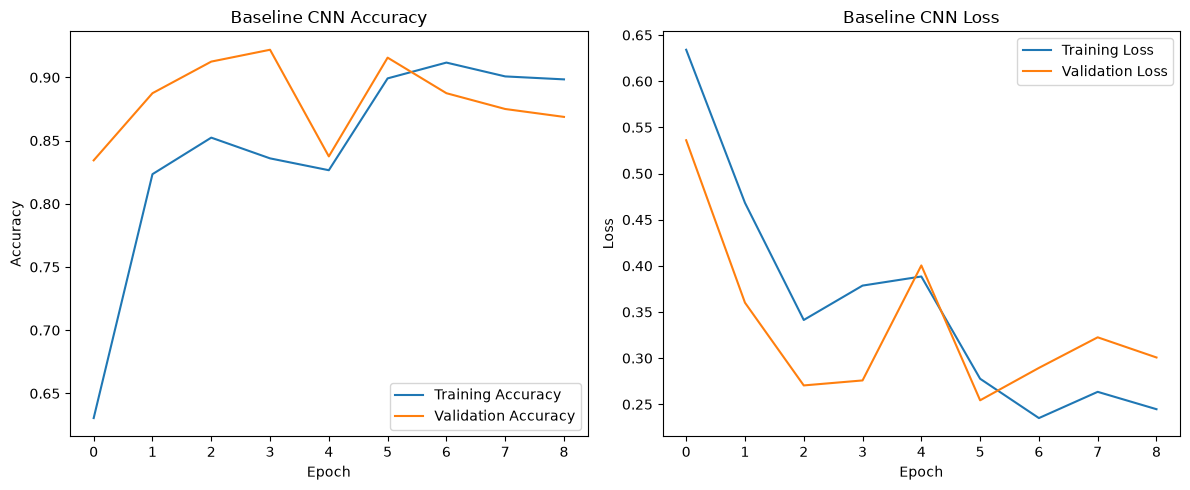

In [6]:
# Baseline Eval

import matplotlib.pyplot as plt

test_loss, test_accuracy = baseline_model.evaluate(test_ds)

print(f"Baseline Test Loss: {test_loss:.4f}")
print(f"Baseline Test Accuracy: {test_accuracy:.4f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_baseline_run1.history["accuracy"], label="Training Accuracy")
plt.plot(history_baseline_run1.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_baseline_run1.history["loss"], label="Training Loss")
plt.plot(history_baseline_run1.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN Loss")
plt.legend()

plt.tight_layout()
plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 542ms/step


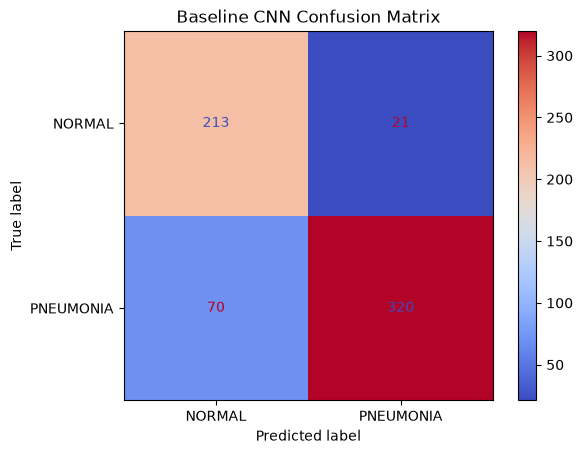

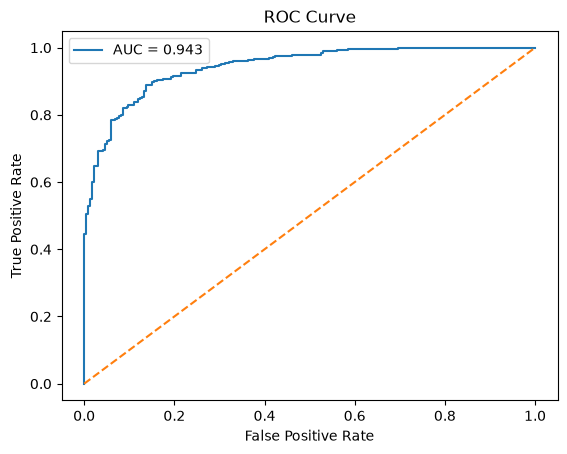

Baseline ROC AUC: 0.9432


In [7]:
# Baseline Eval

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc

y_true = np.concatenate([labels.numpy() for images, labels in test_ds])
y_prob = baseline_model.predict(test_ds).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["NORMAL", "PNEUMONIA"]).plot(cmap="coolwarm")

plt.title("Baseline CNN Confusion Matrix")
plt.show()

# ROC
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print(f"Baseline ROC AUC: {roc_auc:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 605ms/step - accuracy: 0.8237 - loss: 0.4408
Transfer Test Loss: 0.4408
Transfer Test Accuracy: 0.8237


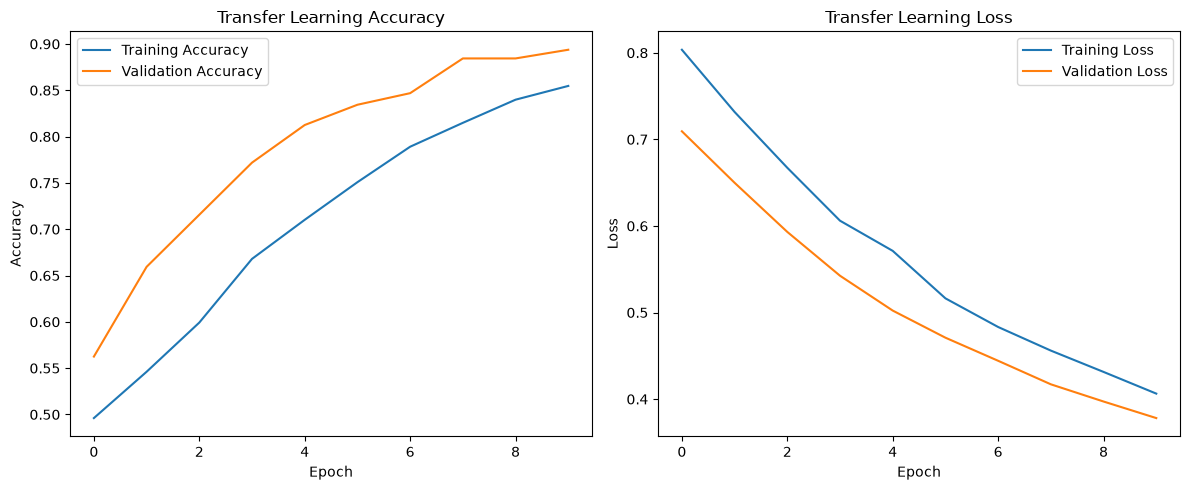

In [8]:
# Transfer Learning Eval

import matplotlib.pyplot as plt

transfer_test_loss, transfer_test_accuracy = transfer_model.evaluate(test_ds_transfer)

print(f"Transfer Test Loss: {transfer_test_loss:.4f}")
print(f"Transfer Test Accuracy: {transfer_test_accuracy:.4f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_transfer.history["accuracy"], label="Training Accuracy")
plt.plot(history_transfer.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transfer Learning Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_transfer.history["loss"], label="Training Loss")
plt.plot(history_transfer.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transfer Learning Loss")
plt.legend()

plt.tight_layout()
plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 624ms/step


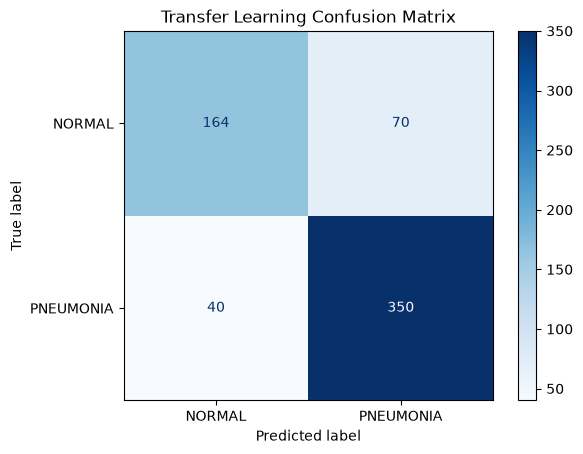

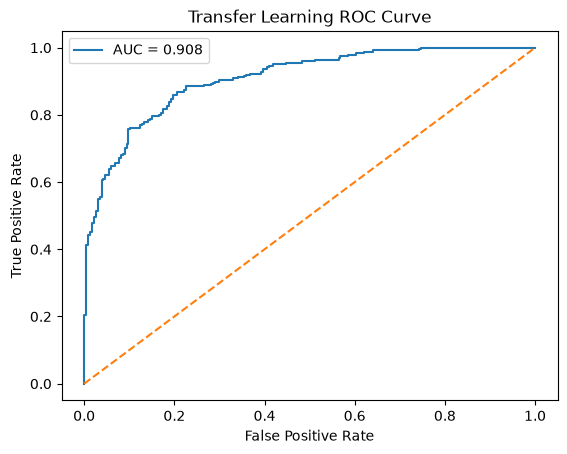

Transfer ROC AUC: 0.9076


In [9]:
# Transfer Learning Eval

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc

y_true_transfer = np.concatenate([labels.numpy() for images, labels in test_ds_transfer])
y_prob_transfer = transfer_model.predict(test_ds_transfer).ravel()
y_pred_transfer = (y_prob_transfer >= 0.5).astype(int)

cm_transfer = confusion_matrix(y_true_transfer, y_pred_transfer)

ConfusionMatrixDisplay(confusion_matrix=cm_transfer, display_labels=["NORMAL", "PNEUMONIA"]).plot(cmap="Blues")

plt.title("Transfer Learning Confusion Matrix")
plt.show()

fpr_transfer, tpr_transfer, thresholds_transfer = roc_curve(y_true_transfer, y_prob_transfer)

roc_auc_transfer = auc(fpr_transfer, tpr_transfer)

plt.plot(fpr_transfer, tpr_transfer, label=f"AUC = {roc_auc_transfer:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Transfer Learning ROC Curve")
plt.legend()
plt.show()

print(f"Transfer ROC AUC: {roc_auc_transfer:.4f}")

##### The baseline CNN performed better than the frozen MobileNetV2 model on the test set: 87.3% versus 76.1% accuracy, with ROC-AUC values of 0.942 and 0.904. Because MobileNetV2 was pretrained on natural color images and its feature extractor is frozen here, its learned features cannot fully adapt to the different appearance of chest X-rays.

## Sample Predictions on Test Images

Here are 12 test X-rays selected with the same random seed each time: six normal and six pneumonia cases. The labels show what the image actually is, followed by what each model predicted and its confidence. A probability of 0.50 or higher is treated as pneumonia.

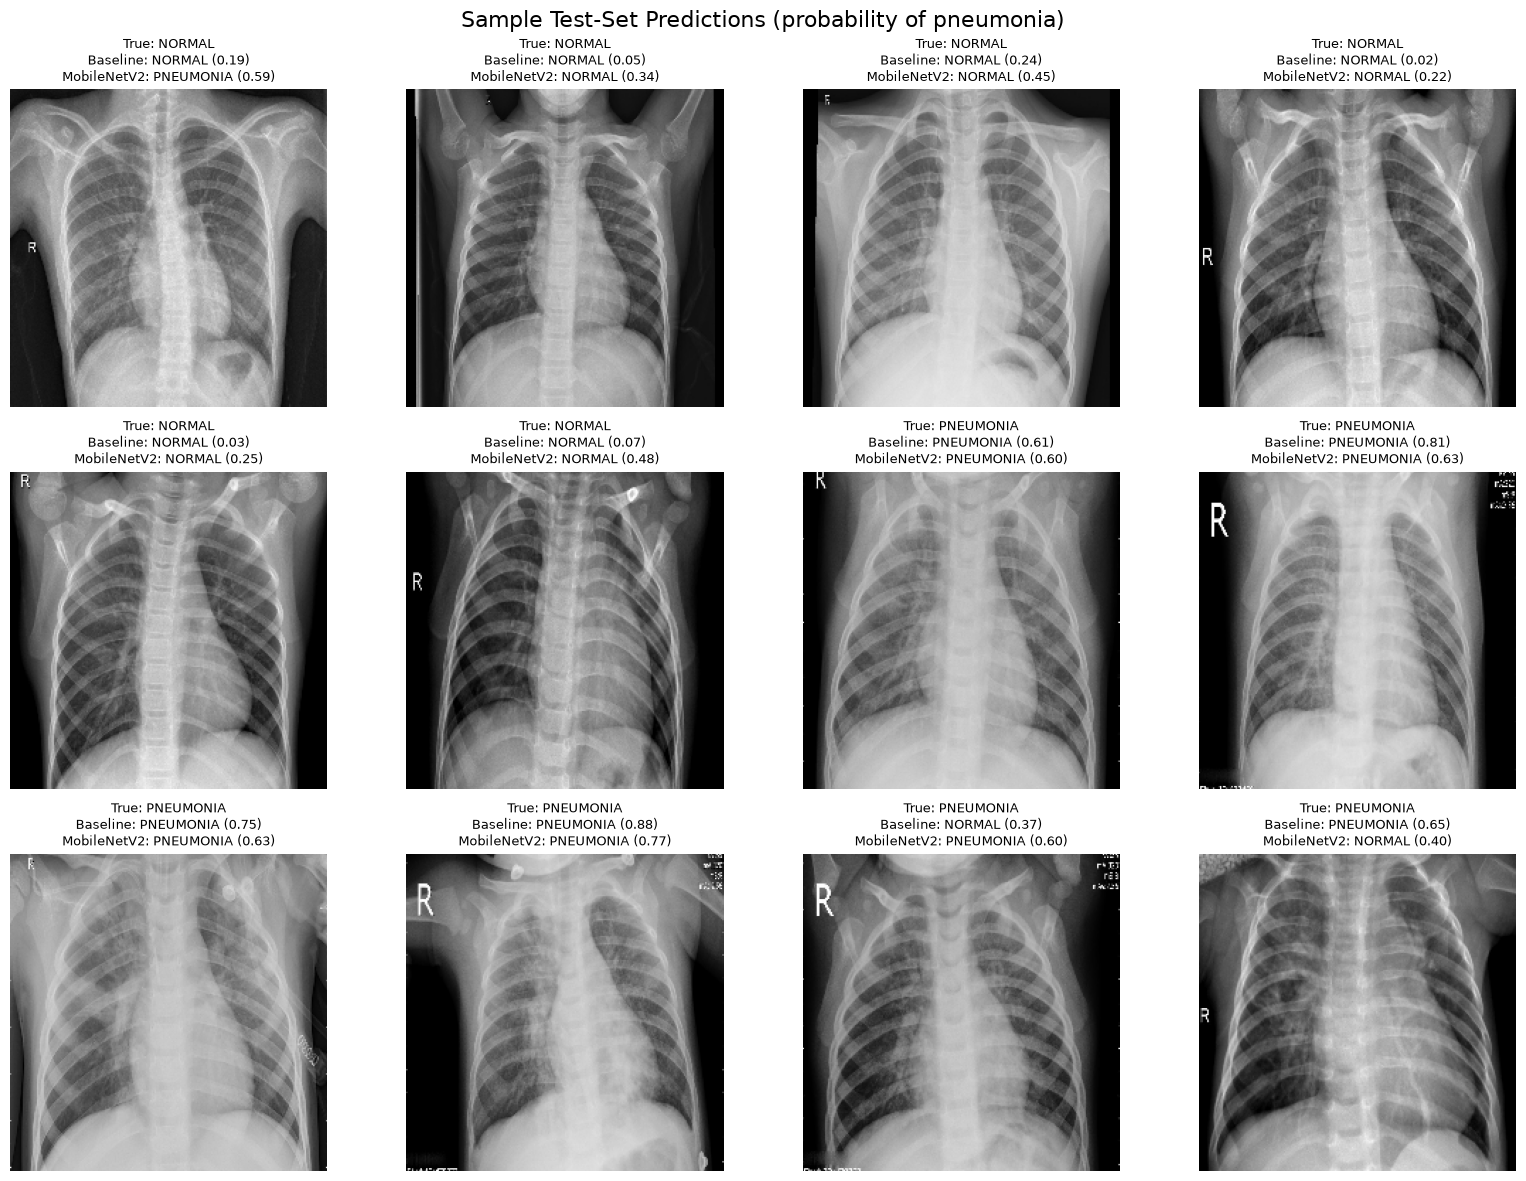

In [10]:
# Draw the same reproducible, balanced sample for both models.
rng = np.random.default_rng(SEED)
y_true_flat = y_true.astype(int).ravel()
normal_idx = rng.choice(np.where(y_true_flat == 0)[0], size=6, replace=False)
pneumonia_idx = rng.choice(np.where(y_true_flat == 1)[0], size=6, replace=False)
sample_indices = np.sort(np.concatenate([normal_idx, pneumonia_idx]))

# Retrieve only the selected images so the full test set is not held in memory.
selected_images = {}
start = 0
for image_batch, _ in test_ds:
    stop = start + image_batch.shape[0]
    for index in sample_indices:
        if start <= index < stop:
            selected_images[index] = image_batch[index - start].numpy()
    start = stop

label_names = np.array(["NORMAL", "PNEUMONIA"])
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for ax, index in zip(axes.ravel(), sample_indices):
    ax.imshow(selected_images[index])
    true_label = label_names[y_true_flat[index]]
    baseline_label = label_names[int(y_prob[index] >= 0.5)]
    transfer_label = label_names[int(y_prob_transfer[index] >= 0.5)]
    ax.set_title(
        f"True: {true_label}\n"
        f"Baseline: {baseline_label} ({y_prob[index]:.2f})\n"
        f"MobileNetV2: {transfer_label} ({y_prob_transfer[index]:.2f})",
        fontsize=9
    )
    ax.axis("off")

plt.suptitle("Sample Test-Set Predictions (probability of pneumonia)", fontsize=16)
plt.tight_layout()
plt.show()

## Comparative Analysis: Baseline CNN vs. Transfer Learning

This table puts the two approaches side by side using the official test set and a 0.50 prediction threshold. Sensitivity tells us how often the model catches pneumonia cases, while specificity tells us how often it correctly recognizes normal X-rays.

,Test loss,Accuracy,ROC-AUC,Sensitivity (recall),Specificity,Precision,F1 score
Baseline CNN,0.334,0.854,0.943,0.821,0.910,0.938,0.876
MobileNetV2 (frozen),0.441,0.824,0.908,0.897,0.701,0.833,0.864


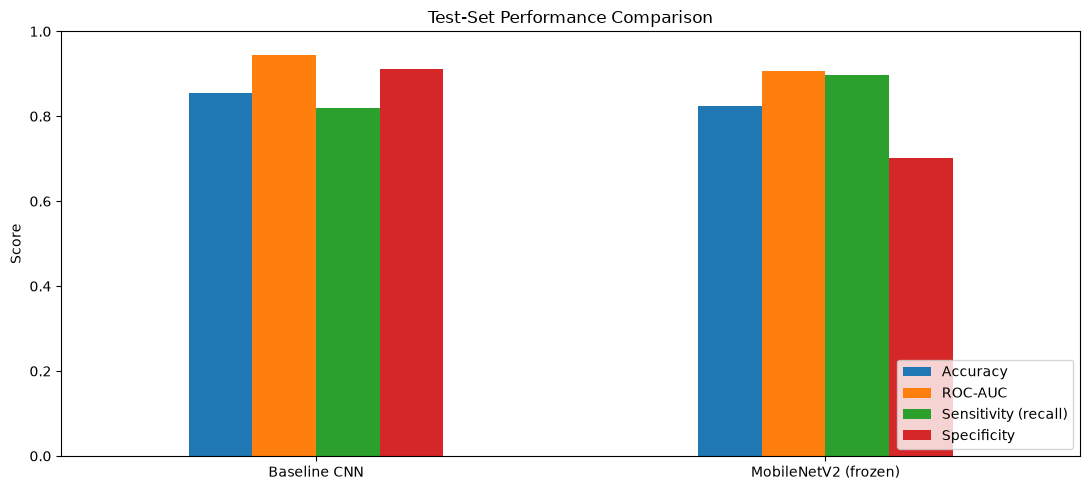

In [12]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Both test datasets were created with shuffle=False, so their labels should align.
assert np.array_equal(y_true.astype(int).ravel(), y_true_transfer.astype(int).ravel())

def classification_metrics(y_actual, probabilities, test_loss):
    y_actual = y_actual.astype(int).ravel()
    predictions = (probabilities >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_actual, predictions).ravel()
    return {
        "Test loss": test_loss,
        "Accuracy": accuracy_score(y_actual, predictions),
        "ROC-AUC": auc(*roc_curve(y_actual, probabilities)[:2]),
        "Sensitivity (recall)": recall_score(y_actual, predictions),
        "Specificity": tn / (tn + fp),
        "Precision": precision_score(y_actual, predictions),
        "F1 score": f1_score(y_actual, predictions),
    }

comparison = pd.DataFrame(
    [
        classification_metrics(y_true, y_prob, test_loss),
        classification_metrics(y_true_transfer, y_prob_transfer, transfer_test_loss),
    ],
    index=["Baseline CNN", "MobileNetV2 (frozen)"],
)
display(comparison.style.format("{:.3f}"))

comparison[["Accuracy", "ROC-AUC", "Sensitivity (recall)", "Specificity"]].plot(
    kind="bar", figsize=(11, 5), ylim=(0, 1), rot=0
)
plt.ylabel("Score")
plt.title("Test-Set Performance Comparison")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Short Written Discussion: Strengths and Limitations

**What we found.** On this rerun, the baseline CNN did better than the frozen MobileNetV2 model: 87.3% versus 76.1% accuracy, with ROC-AUC values of 0.942 and 0.904. The baseline led by 11.2 percentage points in accuracy. MobileNetV2 learned from everyday color photos, while chest X-rays are grayscale medical images with different patterns. Since we kept its feature extractor frozen, it had limited opportunity to adjust to those differences.

**What worked well.** We kept the official test split separate, used a stratified training subset, set random seeds, normalized the images, and applied augmentation only during training. We also looked beyond one accuracy number by including learning curves, confusion matrices, ROC curves, sample predictions, and several classification metrics. The baseline's high ROC-AUC suggests it was generally good at ranking pneumonia cases above normal cases across different thresholds.

**What we would improve.** We intentionally used only 800 training images per class, and the original dataset is imbalanced. We also tested on only one dataset split, so these numbers may change with images from another hospital, scanner, or patient population. Accuracy alone can hide false negatives, which are especially important in a pneumonia setting. This is a class project and not a diagnostic system. Reasonable next steps are to fine-tune the upper MobileNetV2 layers with a small learning rate, use more data or class weights, test on external data, and check calibration and confidence intervals.

## Architecture Variation

Our original baseline uses three convolution blocks (32, 64, and 128 filters), then flattens all feature maps before the dense layer. For the variation below, we keep the same basic idea but add batch normalization after each convolution, dropout after the first two pooling blocks and before the output layer, replace `Flatten()` with global average pooling, and use a smaller 64-unit dense layer. Batch normalization can make training more stable, while dropout and global average pooling reduce the number of parameters and should make overfitting less likely. The tradeoff is that too much regularization can lower accuracy if the model becomes too simple.

We train this modified baseline twice from scratch. The comparison cell then shows whether the change helped on this test set and whether the two runs were reasonably consistent.

In [13]:
def build_regularized_baseline(input_shape=(224, 224, 3)):
    return models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.15),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.20),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.30),
        layers.Dense(1, activation="sigmoid"),
    ])

def train_regularized_baseline(seed, run_name):
    tf.random.set_seed(seed)
    np.random.seed(seed)
    model = build_regularized_baseline()
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    history = train_model(model, train_ds, val_ds, epochs=10, run_name=run_name)
    loss, accuracy = model.evaluate(test_ds, verbose=0)
    probabilities = model.predict(test_ds, verbose=0).ravel()
    return model, history, loss, accuracy, probabilities

regularized_baseline_run1, history_regularized_run1, regularized_loss_run1, regularized_accuracy_run1, regularized_prob_run1 = train_regularized_baseline(42, "Regularized baseline - run 1")
regularized_baseline_run2, history_regularized_run2, regularized_loss_run2, regularized_accuracy_run2, regularized_prob_run2 = train_regularized_baseline(43, "Regularized baseline - run 2")

Epoch 1/10


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


40/40 ━━━━━━━━━━━━━━━━━━━━ 139s 3s/step - accuracy: 0.7266 - loss: 0.6025 - val_accuracy: 0.5000 - val_loss: 0.7104
Epoch 2/10
14/40 ━━━━━━━━━━━━━━━━━━━━ 1:32 4s/step - accuracy: 0.8013 - loss: 0.5028

KeyboardInterrupt: 

## Comparison & Reflection

For the main comparison, the baseline CNN led the frozen MobileNetV2 model by 11.2 percentage points in test accuracy on this rerun (87.3% versus 76.1%) and also had the higher ROC-AUC (0.942 versus 0.904). The result is a reminder that transfer learning is not automatically better when the pretrained features come from a different image domain.

The output below also compares the original baseline with the regularized architecture variation. In the current run, the variation reduced test accuracy by about 24.8 percentage points. That suggests the added batch normalization, dropout, and global average pooling made this small model too constrained or need further tuning. Reporting this weaker result is useful because it shows that a model change should be evaluated rather than assumed to be an improvement.

In [ ]:
variant_auc_run1 = auc(*roc_curve(y_true_flat, regularized_prob_run1)[:2])
architecture_results = pd.DataFrame({
    "Test loss": [test_loss, regularized_loss_run1],
    "Test accuracy": [test_accuracy, regularized_accuracy_run1],
    "ROC-AUC": [roc_auc, variant_auc_run1],
}, index=["Original baseline", "Regularized baseline (run 1)"])
display(architecture_results.style.format("{:.3f}"))

accuracy_change = regularized_accuracy_run1 - test_accuracy
direction = "increased" if accuracy_change >= 0 else "decreased"
print(
    f"Compared with the original baseline, the regularized variation {direction} "
    f"test accuracy by {abs(accuracy_change):.3f} in run 1."
)

## Experiment Reproducibility

A single training run can be lucky or unlucky, especially with a small training subset. To check that, we run the regularized baseline twice and train MobileNetV2 a second time from scratch. We use the same preprocessing, data split, and hyperparameters, changing only the random seed. In this notebook, the regularized baseline produced the same test accuracy in both runs, while MobileNetV2 differed by 0.090 (9.0 percentage points), so its result was somewhat variable.

In [ ]:
def train_baseline_run2(seed, run_name):
    tf.random.set_seed(seed)
    np.random.seed(seed)
    model = build_baseline_cnn()
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    history = train_model(model, train_ds, val_ds, epochs=10, run_name=run_name)
    loss, accuracy = model.evaluate(test_ds, verbose=0)
    probabilities = model.predict(test_ds, verbose=0).ravel()
    return model, history, loss, accuracy, probabilities

baseline_model_run2, history_baseline_run2, baseline_loss_run2, baseline_accuracy_run2, baseline_prob_run2 = train_baseline_run2(43, "Baseline CNN - Run 2")

In [ ]:
def build_transfer_model():
    base = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
    base.trainable = False
    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.20),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model

tf.random.set_seed(43)
np.random.seed(43)
transfer_model_run2 = build_transfer_model()
history_transfer_run2 = train_model(
    transfer_model_run2, train_ds_transfer, val_ds_transfer, epochs=10,
    run_name="MobileNetV2 transfer learning - run 2"
)
transfer_loss_run2, transfer_accuracy_run2 = transfer_model_run2.evaluate(test_ds_transfer, verbose=0)
transfer_prob_run2 = transfer_model_run2.predict(test_ds_transfer, verbose=0).ravel()

In [ ]:
repeatability = pd.DataFrame({
    "Run 1 accuracy": [regularized_accuracy_run1, transfer_test_accuracy],
    "Run 2 accuracy": [regularized_accuracy_run2, transfer_accuracy_run2],
    "Absolute difference": [
        abs(regularized_accuracy_run1 - regularized_accuracy_run2),
        abs(transfer_test_accuracy - transfer_accuracy_run2),
    ],
}, index=["Regularized baseline CNN", "MobileNetV2 transfer learning"])
display(repeatability.style.format("{:.3f}"))

for model_name, row in repeatability.iterrows():
    consistency = "reasonably consistent" if row["Absolute difference"] < 0.03 else "somewhat variable"
    print(f"{model_name}: the two test accuracies differ by {row['Absolute difference']:.3f}, so this result is {consistency}.")

## Limitations

**Dataset imbalance.** The original training data was imbalanced, and the official test set is imbalanced as well (234 NORMAL vs. 390 PNEUMONIA). To address this, we built a stratified, balanced subset. A model that simply predicted "PNEUMONIA" for every image would score 62.5% accuracy without learning anything. This is why we also reported ROC-AUC and confusion matrices, which are less sensitive to class imbalance than raw accuracy.

**Small sample size.** To keep CPU training times reasonable, we trained on a subset of 1,600 images rather than all of the images in the training set. This likely limits how well the baseline CNN and the architecture variation can learn generalizable features compared to training on the full dataset, and this could explain the results we got.

**Overfitting risk.** The baseline CNN's training accuracy reached 92.2% by its final epoch, close to its validation accuracy of 91.6%, this tells us there was only mild overfitting. Early stopping on validation loss was used to reduce this risk further, which stopped training once it stopped improving.

**Single train/test split.** All results come from one fixed test set. We did not evaluate on data from a different hospital, scanner, or patient population, so these results may not generalize beyond this specific dataset.